(15)=
# Chapter 15: Numerical Integration and Differentiation

**Topics Covered:**
- Numerical differentiation with `np.gradient`
- Trapezoidal rule: `scipy.integrate.trapezoid`
- General-purpose quadrature: `scipy.integrate.quad`
- Cumulative integration: `scipy.integrate.cumulative_trapezoid`
- ChE application: PFR design and the Levenspiel integral

## Motivation: Two Problems You Can't Solve by Hand

**Problem 1 — How much heat does it take?**

The heat capacity of nitrogen gas is not constant — it varies with temperature. To heat 1 mol of N₂ from 300 K to 1200 K, you need:

$$\Delta H = \int_{300}^{1200} C_p(T) \, dT$$

where $C_p(T)$ follows the NIST Shomate equation. You could try to integrate this polynomial by hand, but what if your $C_p$ data comes from a table of measurements rather than a formula?

**Problem 2 — What is the reaction rate at each time step?**

In a batch reactor experiment, you measure concentration $C_A$ at discrete time points. The reaction rate is:
$$r_A = -\frac{dC_A}{dt}$$

But you don't have a formula for $C_A(t)$ — only a table of numbers. How do you compute a derivative from data?

Both problems need **numerical** methods. Let's look at the tools Python gives us.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, trapezoid, cumulative_trapezoid

(15.1)=
## 15.1 The Core Idea: Integration and Differentiation Geometrically

Before writing any code, let's make the geometry clear.

- **Integration** = the area under a curve between two limits
- **Differentiation** = the slope of a curve at a point

When you have a smooth analytic function, calculus gives exact answers. When you have **discrete data** or a **complicated expression**, you use numerical approximations instead.

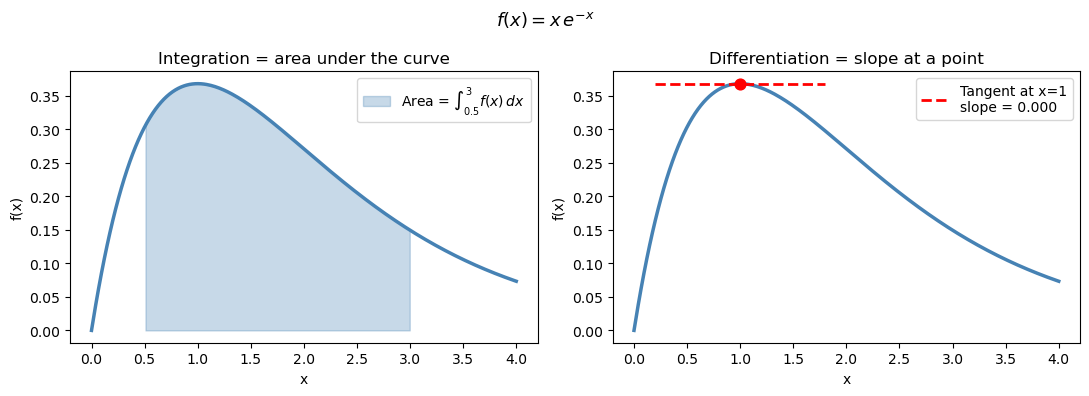

In [2]:
x = np.linspace(0, 4, 300)
f = x * np.exp(-x)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: integration = area under curve
ax = axes[0]
ax.plot(x, f, 'steelblue', linewidth=2.5)
mask = (x >= 0.5) & (x <= 3.0)
ax.fill_between(x[mask], f[mask], alpha=0.3, color='steelblue', label=r'Area = $\int_{0.5}^{3} f(x)\,dx$')
ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.set_title('Integration = area under the curve')
ax.legend(fontsize=10)

# Right: differentiation = slope at a point
ax = axes[1]
ax.plot(x, f, 'steelblue', linewidth=2.5)
x0 = 1.0
f0 = x0 * np.exp(-x0)
dfdx0 = np.exp(-x0) - x0 * np.exp(-x0)   # exact derivative: e^{-x}(1-x)
x_tan = np.linspace(0.2, 1.8, 50)
ax.plot(x_tan, f0 + dfdx0 * (x_tan - x0), 'r--', linewidth=2, label=f"Tangent at x=1\nslope = {dfdx0:.3f}")
ax.scatter([x0], [f0], color='red', s=60, zorder=5)
ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.set_title('Differentiation = slope at a point')
ax.legend(fontsize=10)

plt.suptitle(r'$f(x) = x\,e^{-x}$', fontsize=13)
plt.tight_layout()
plt.show()

(15.2)=
## 15.2 Numerical Differentiation: `np.gradient`

### The mathematics: finite difference formulas

A derivative is defined by the limit:
$$f'(x) = \lim_{\Delta x \to 0} \frac{f(x + \Delta x) - f(x)}{\Delta x}$$

When you only have data at discrete points $x_0, x_1, \ldots, x_n$, you can't take the limit — but you can approximate it using nearby values. These approximations are called **finite difference formulas**.

**Central difference** (used at interior points — most accurate):
$$f'(x_i) \approx \frac{f(x_{i+1}) - f(x_{i-1})}{x_{i+1} - x_{i-1}}$$

This is second-order accurate: the error shrinks like $(\Delta x)^2$. It uses symmetric information on both sides of $x_i$.

**Forward difference** (used at the left endpoint, where no left neighbor exists):
$$f'(x_0) \approx \frac{f(x_1) - f(x_0)}{x_1 - x_0}$$

**Backward difference** (used at the right endpoint, where no right neighbor exists):
$$f'(x_n) \approx \frac{f(x_n) - f(x_{n-1})}{x_n - x_{n-1}}$$

The forward and backward formulas are only first-order accurate — the error shrinks like $\Delta x$, not $(\Delta x)^2$. This is why numerical derivatives are slightly less accurate at the endpoints.

`np.gradient` applies these three formulas automatically and returns one derivative value per data point — the output array is the **same length** as the input.

### Key Python syntax

```python
dydx = np.gradient(y, x)
```

- **`y`** — array of function values (what you measured)
- **`x`** — array of corresponding $x$ positions; **always pass this** when your $x$-spacing is not 1
- **Returns** — array of the same length as `y`, one $dy/dx$ value per point

```{warning}
If you write `np.gradient(y)` without `x`, NumPy assumes unit spacing ($\Delta x = 1$). The result is wrong whenever your data has physical units like seconds or Kelvin.
```

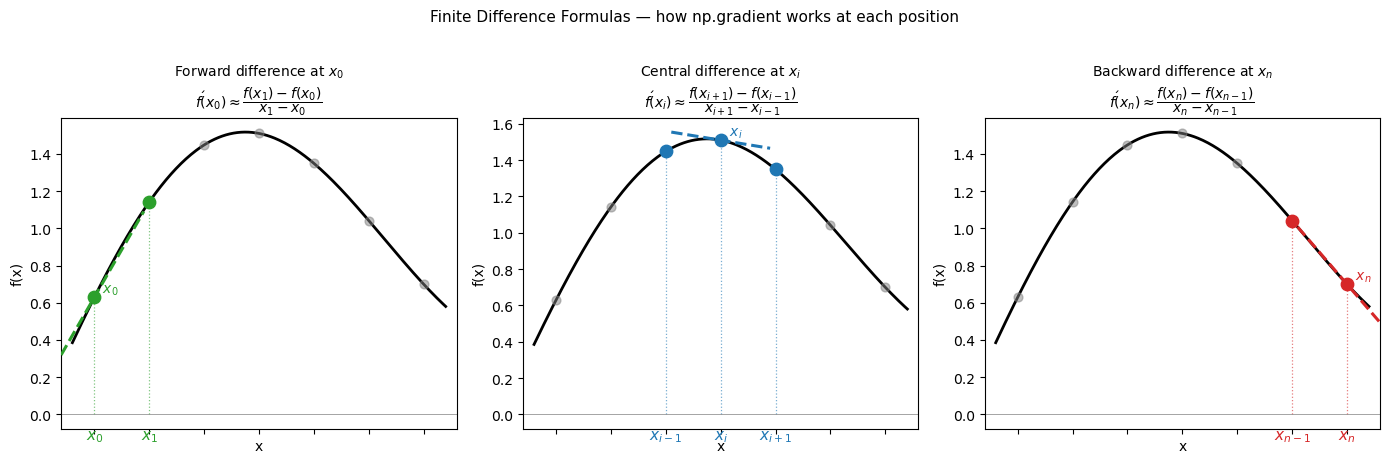

In [3]:

# Visualize: Forward, Backward, and Central Difference formulas
# on a small discrete dataset, labeling x_0, x_1, x_{i-1}, x_i, x_{i+1}, x_{n-1}, x_n

# Use a smooth function sampled at a handful of points
x_pts = np.linspace(0.5, 3.5, 7)          # x_0 … x_n  (n=6)
f_pts = np.sin(x_pts) + 0.3 * x_pts       # arbitrary smooth function

x_fine = np.linspace(0.3, 3.7, 300)
f_fine = np.sin(x_fine) + 0.3 * x_fine

# Pick a representative interior index i = 3
i = 3

# ---------- slope line helpers ----------
def tangent_segment(x0, y0, slope, half_width=0.35):
    xs = np.array([x0 - half_width, x0 + half_width])
    ys = y0 + slope * (xs - x0)
    return xs, ys

# Forward difference at x_0
fwd_slope  = (f_pts[1]  - f_pts[0])  / (x_pts[1]  - x_pts[0])
# Backward difference at x_n
bwd_slope  = (f_pts[-1] - f_pts[-2]) / (x_pts[-1] - x_pts[-2])
# Central difference at x_i
cen_slope  = (f_pts[i+1] - f_pts[i-1]) / (x_pts[i+1] - x_pts[i-1])

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=False)

titles = [
    r'Forward difference at $x_0$' + '\n'
    r'$f\'(x_0)\approx\dfrac{f(x_1)-f(x_0)}{x_1-x_0}$',

    r'Central difference at $x_i$' + '\n'
    r'$f\'(x_i)\approx\dfrac{f(x_{i+1})-f(x_{i-1})}{x_{i+1}-x_{i-1}}$',

    r'Backward difference at $x_n$' + '\n'
    r'$f\'(x_n)\approx\dfrac{f(x_n)-f(x_{n-1})}{x_n-x_{n-1}}$',
]

configs = [
    # (focus_idx, left_idx, right_idx, slope, color)
    (0,   None, 1,    fwd_slope, 'tab:green'),
    (i,   i-1,  i+1,  cen_slope, 'tab:blue'),
    (-1,  -2,   None, bwd_slope, 'tab:red'),
]

# label map: index -> LaTeX label
def get_label(idx, n=6):
    mapping = {0: r'$x_0$', 1: r'$x_1$', n-1: r'$x_{n-1}$', n: r'$x_n$'}
    return mapping.get(idx, None)

for ax, title, (fi, li, ri, slope, color) in zip(axes, titles, configs):
    ax.plot(x_fine, f_fine, 'k-', linewidth=2, zorder=1)
    ax.scatter(x_pts, f_pts, color='gray', s=40, zorder=3, alpha=0.5)

    focus_x = x_pts[fi]
    focus_y = f_pts[fi]

    # highlight the points used in the formula
    used_idx = [idx for idx in [li, fi, ri] if idx is not None]
    ax.scatter(x_pts[used_idx], f_pts[used_idx], color=color, s=80, zorder=5)

    # draw the secant / slope line
    xs_t, ys_t = tangent_segment(focus_x, focus_y, slope, half_width=0.45)
    ax.plot(xs_t, ys_t, color=color, linewidth=2.2, linestyle='--', label='approx slope', zorder=4)

    # vertical dashed lines to x-axis for used points
    for idx in used_idx:
        ax.plot([x_pts[idx], x_pts[idx]], [0, f_pts[idx]],
                color=color, linewidth=0.9, linestyle=':', alpha=0.6)

    # annotate x-axis tick labels
    n = len(x_pts) - 1  # n = 6
    label_map = {0: r'$x_0$', 1: r'$x_1$',
                 i-1: r'$x_{i-1}$', i: r'$x_i$', i+1: r'$x_{i+1}$',
                 n-1: r'$x_{n-1}$', n: r'$x_n$'}
    for idx in used_idx:
        raw = idx if idx >= 0 else n + 1 + idx  # convert negative index
        lbl = label_map.get(raw, None)
        if lbl:
            ax.annotate(lbl, xy=(x_pts[idx], 0),
                        xytext=(0, -18), textcoords='offset points',
                        ha='center', fontsize=11, color=color)

    # annotate the focus point on the curve
    raw_fi = fi if fi >= 0 else n + 1 + fi
    focus_lbl = label_map.get(raw_fi, r'$x_i$')
    ax.annotate(f'  {focus_lbl}', xy=(focus_x, focus_y),
                fontsize=10, color=color, va='bottom')

    ax.set_title(title, fontsize=10, pad=8)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.set_xlim(0.2, 3.8)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.tick_params(labelbottom=False)   # hide numeric ticks; we use latex labels

plt.suptitle('Finite Difference Formulas — how np.gradient works at each position',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('finite_difference_formulas.png', dpi=300, bbox_inches='tight')
plt.show()


### Syntax Practice: `np.gradient`

Before verifying on a known function, try the syntax yourself on a simple dataset.

**Given** position data sampled every 0.5 seconds:

| $t$ (s) | 0.0 | 0.5 | 1.0 | 1.5 | 2.0 |
|---------|-----|-----|-----|-----|-----|
| $x$ (m) | 0.0 | 1.2 | 2.1 | 2.7 | 3.0 |

**Task:** Compute the velocity $v = dx/dt$ at each time point using `np.gradient`.

```python
t = np.array([0.0, 0.5, 1.0, 1.5, 2.0])
x = np.array([0.0, 1.2, 2.1, 2.7, 3.0])

# Your turn: compute v = dx/dt at every point
v = np.gradient(???, ???)

print("t (s):", t)
print("v (m/s):", v)
```

Notice:
- `v[0]` uses the **forward** formula ($x_0, x_1$)
- `v[1]`, `v[2]`, `v[3]` use the **central** formula
- `v[-1]` uses the **backward** formula ($x_{n-1}, x_n$)


In [7]:
t = np.array([0.0, 0.5, 1.0, 1.5, 2.0])
x = np.array([0.0, 1.2, 2.1, 2.7, 3.0])

# Compute v = dx/dt at every point ; x(t)
v = np.gradient(x, t)

print("t (s):", t)
print("v (m/s):", np.round(v, 4))

# Which formula was used at each point?
print("\nFormula used:")
print(f"  v[0]  = (x[1]-x[0])/(t[1]-t[0])           = {(x[1]-x[0])/(t[1]-t[0]):.4f}  ← forward") # one neighbor
print(f"  v[2]  = (x[3]-x[1])/(t[3]-t[1])           = {(x[3]-x[1])/(t[3]-t[1]):.4f}  ← centeral") # two neighbors
print(f"  v[-1]  = (x[-1]-x[-2])/(t[-1]-t[-2])           = {(x[-1]-x[-2])/(t[-1]-t[-2]):.4f}  ← backward") # one neighbor

t (s): [0.  0.5 1.  1.5 2. ]
v (m/s): [2.4 2.1 1.5 0.9 0.6]

Formula used:
  v[0]  = (x[1]-x[0])/(t[1]-t[0])           = 2.4000  ← forward
  v[2]  = (x[3]-x[1])/(t[3]-t[1])           = 1.5000  ← centeral
  v[-1]  = (x[-1]-x[-2])/(t[-1]-t[-2])           = 0.6000  ← backward


### 15.2.1 Verification on a known function

Let's check `np.gradient` against the exact derivative of $\sin(x)$ (which is $\cos(x)$).

For a uniform grid with spacing $h$, the central difference error is proportional to $h^2 f'''(x)/6$. With 50 points over $[0, 2\pi]$, $h \approx 0.13$, so we expect the max error to be on the order of $h^2 \approx 0.017$ — consistent with what we observe below.

Max absolute error vs exact cos(x): 2.74e-03


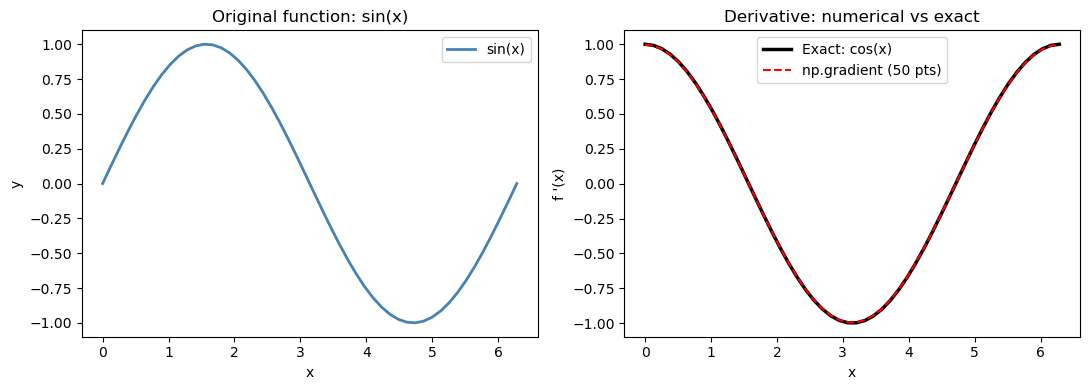

In [16]:
x_sin = np.linspace(0, 2 * np.pi, 50)
y_sin = np.sin(x_sin)

# Numerical derivative
dy_num = np.gradient(y_sin, x_sin)

# Exact derivative
dy_exact = np.cos(x_sin)

#print(np.abs(dy_num - dy_exact))

max_error = np.max(np.abs(dy_num - dy_exact))
print(f"Max absolute error vs exact cos(x): {max_error:.2e}")


fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
ax.plot(x_sin, y_sin, 'steelblue', linewidth=2, label='sin(x)')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Original function: sin(x)')
ax.legend()

ax = axes[1]
ax.plot(x_sin, dy_exact, 'k-',  linewidth=2.5, label='Exact: cos(x)')
ax.plot(x_sin, dy_num,   'r--', linewidth=1.5, label='np.gradient (50 pts)')
ax.set_xlabel('x'); ax.set_ylabel("f '(x)")
ax.set_title('Derivative: numerical vs exact')
ax.legend()

plt.tight_layout()
plt.show()

### 15.2.2 Reaction rate from concentration data

In a batch reactor experiment, $C_A$ is measured at discrete time points. The reaction rate of disappearance of A is defined as:
$$r_A = -\frac{dC_A}{dt}$$

The negative sign converts the *decrease* in concentration into a positive rate. We only have a table of numbers — no formula for $C_A(t)$ — so `np.gradient` is the right tool.

Notice how `np.gradient` applies the central difference at interior points and the one-sided (forward/backward) difference at the two endpoints $t=0$ and $t=60$. You can verify this in the printed table: the values at the boundaries use only one neighbor.

 t (s)   C_A (mol/L)   r_A (mol/L·s)
--------------------------------------
     0         1.000         0.02200
    10         0.780         0.01950
    20         0.610         0.01500
    30         0.480         0.01200
    40         0.370         0.00950
    50         0.290         0.00700
    60         0.230         0.00600


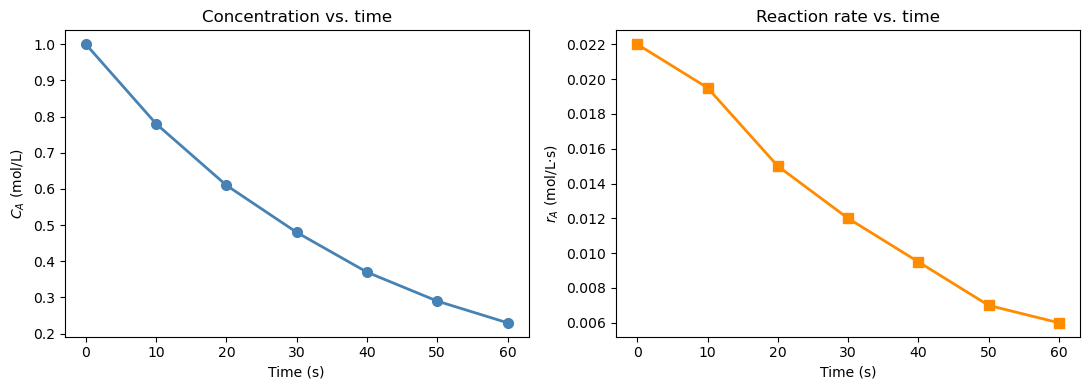

In [18]:
t   = np.array([0,    10,   20,   30,   40,   50,   60  ])  # s
C_A = np.array([1.00, 0.78, 0.61, 0.48, 0.37, 0.29, 0.23])  # mol/L

# Reaction rate: r_A = -dC_A/dt
# IMPORTANT: pass t as the second argument — spacing is 10 s, not 1
r_A = - np.gradient(C_A, t)

print(f"{'t (s)':>6}  {'C_A (mol/L)':>12}  {'r_A (mol/L·s)':>14}")
print("-" * 38)
for i in range(len(t)):
    print(f"  {t[i]:>4.0f}  {C_A[i]:>12.3f}  {r_A[i]:>14.5f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(t, C_A, 'o-', color='steelblue', linewidth=2, markersize=7)
ax.set_xlabel('Time (s)'); ax.set_ylabel('$C_A$ (mol/L)')
ax.set_title('Concentration vs. time')

ax = axes[1]
ax.plot(t, r_A, 's-', color='darkorange', linewidth=2, markersize=7)
ax.set_xlabel('Time (s)'); ax.set_ylabel('$r_A$ (mol/L·s)')
ax.set_title('Reaction rate vs. time')

plt.tight_layout()
plt.show()

(15.3)=
## 15.3 Numerical Integration of Discrete Data: Trapezoidal Rule

### The mathematics: deriving the formula

The trapezoidal rule approximates the area under a curve by connecting adjacent data points with **straight lines** and summing the resulting trapezoid areas.

For two adjacent points $(x_i, f_i)$ and $(x_{i+1}, f_{i+1})$, the area of the trapezoid is:
$$A_i = (x_{i+1} - x_i)\bigl(\frac{f_i + f_{i+1}}{2}\bigr)$$

This is just the base times the average height. Summing over all $n-1$ intervals:
$$\int_a^b f(x)\,dx \approx \sum_{i=0}^{n-2} (x_{i+1} - x_i)\bigl(\frac{f_i + f_{i+1}}{2}\bigr)$$

For a **uniform** grid with spacing $h = (b-a)/(n-1)$, this simplifies to:
$$\int_a^b f(x)\,dx \approx h\left[\frac{f_0}{2} + f_1 + f_2 + \cdots + f_{n-2} + \frac{f_{n-1}}{2}\right]$$

The endpoints are weighted by $\frac{1}{2}$ because each endpoint belongs to only one trapezoid, while interior points are shared between two.

**Truncation error:** The trapezoidal rule is second-order accurate — for a uniform grid, the global error is:
$$\text{Error} \approx -\frac{(b-a)^2}{12n^2}\,\bigl[f'(b) - f'(a)\bigr] \sim \mathcal{O}(h^2)$$

Doubling the number of points reduces the error by a factor of 4.
```

### Key Python syntax

```python
from scipy.integrate import trapezoid

area = trapezoid(y, x)
```

- **`y`** — array of function values at the sample points
- **`x`** — array of corresponding $x$ positions; **always pass this** with physical units
- **Returns** — a single float: $\int y\, dx$

```{warning}
`trapezoid(y)` without `x` assumes unit spacing ($\Delta x = 1$) — wrong whenever your $x$-axis has units.

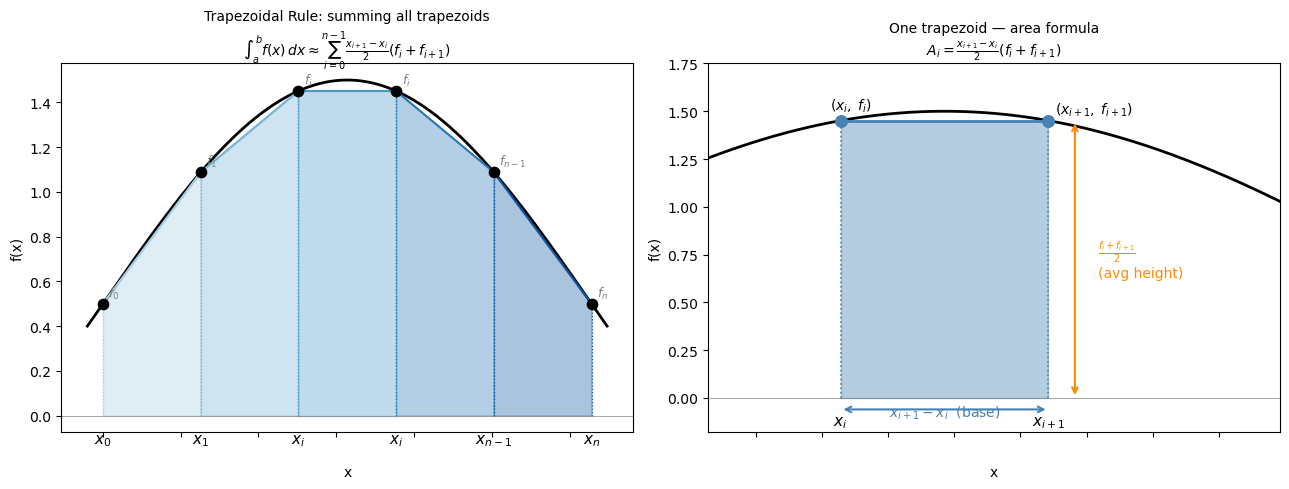

In [20]:

# Visualize the trapezoidal rule formula on a general dataset
# Shows: area = (x_{i+1} - x_i) / 2 * (f_i + f_{i+1}) for each trapezoid

x_trap_vis = np.linspace(0, np.pi, 6)          # x_0 … x_n  (n=5, 6 points)
f_trap_vis = np.sin(x_trap_vis) + 0.5          # arbitrary positive function

x_fine_vis = np.linspace(-0.1, np.pi + 0.1, 400)
f_fine_vis = np.sin(x_fine_vis) + 0.5

n = len(x_trap_vis) - 1  # number of intervals

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left panel: full trapezoidal sum with labeled points ──────────────────────
ax = axes[0]
ax.plot(x_fine_vis, f_fine_vis, 'k-', linewidth=2, zorder=2, label='f(x)')

colors = plt.cm.Blues(np.linspace(0.35, 0.85, n))

for i in range(n):
    xi,  fi  = x_trap_vis[i],   f_trap_vis[i]
    xi1, fi1 = x_trap_vis[i+1], f_trap_vis[i+1]
    ax.fill_between([xi, xi1], [fi, fi1], alpha=0.35, color=colors[i], zorder=1)
    ax.plot([xi, xi1], [fi, fi1], color=colors[i], linewidth=1.5)
    ax.plot([xi,  xi],  [0, fi],  color=colors[i], linewidth=0.9, linestyle=':')
    ax.plot([xi1, xi1], [0, fi1], color=colors[i], linewidth=0.9, linestyle=':')

ax.scatter(x_trap_vis, f_trap_vis, color='black', s=55, zorder=5)

x_labels = {0: r'$x_0$', 1: r'$x_1$', n-1: r'$x_{n-1}$', n: r'$x_n$'}
f_labels  = {0: r'$f_0$', 1: r'$f_1$', n-1: r'$f_{n-1}$', n: r'$f_n$'}
for j, (xv, fv) in enumerate(zip(x_trap_vis, f_trap_vis)):
    ax.annotate(x_labels.get(j, r'$x_i$'), xy=(xv, 0), xytext=(0, -20),
                textcoords='offset points', ha='center', fontsize=11)
    ax.annotate(f_labels.get(j, r'$f_i$'), xy=(xv, fv), xytext=(4, 5),
                textcoords='offset points', fontsize=9, color='gray')

ax.axhline(0, color='gray', linewidth=0.5)
ax.tick_params(labelbottom=False)
ax.set_xlabel('x', labelpad=20)
ax.set_ylabel('f(x)')
ax.set_title(
    'Trapezoidal Rule: summing all trapezoids\n'
    r'$\int_a^b f(x)\,dx \approx \sum_{i=0}^{n-1}'
    r'\frac{x_{i+1}-x_i}{2}(f_i + f_{i+1})$',
    fontsize=10
)

# ── Right panel: zoom into ONE trapezoid, labeling the formula pieces ─────────
ax2 = axes[1]
ax2.plot(x_fine_vis, f_fine_vis, 'k-', linewidth=2, zorder=2)

i_show = 2
xi,  fi  = x_trap_vis[i_show],   f_trap_vis[i_show]
xi1, fi1 = x_trap_vis[i_show+1], f_trap_vis[i_show+1]

ax2.fill_between([xi, xi1], [fi, fi1], alpha=0.4, color='steelblue', zorder=1)
ax2.plot([xi, xi1], [fi, fi1], 'steelblue', linewidth=2)
ax2.plot([xi,  xi],  [0, fi],  'steelblue', linewidth=1.2, linestyle=':')
ax2.plot([xi1, xi1], [0, fi1], 'steelblue', linewidth=1.2, linestyle=':')
ax2.scatter([xi, xi1], [fi, fi1], color='steelblue', s=70, zorder=5)

# double-headed arrow for base width
mid_x = (xi + xi1) / 2
ax2.annotate('', xy=(xi1, -0.06), xytext=(xi, -0.06),
             arrowprops=dict(arrowstyle='<->', color='steelblue', lw=1.5))
ax2.text(mid_x, -0.10, r'$x_{i+1} - x_i$  (base)', ha='center',
         fontsize=10, color='steelblue')

# average height label
avg_h = (fi + fi1) / 2
ax2.annotate('', xy=(xi1 + 0.08, avg_h), xytext=(xi1 + 0.08, 0),
             arrowprops=dict(arrowstyle='<->', color='darkorange', lw=1.5))
ax2.text(xi1 + 0.15, avg_h / 2,
         r'$\frac{f_i + f_{i+1}}{2}$' + '\n(avg height)',
         ha='left', va='center', fontsize=10, color='darkorange')

ax2.annotate(r'$(x_i,\; f_i)$',         xy=(xi,  fi),  xytext=(-8, 8),  textcoords='offset points', fontsize=10)
ax2.annotate(r'$(x_{i+1},\; f_{i+1})$', xy=(xi1, fi1), xytext=(5,  5),  textcoords='offset points', fontsize=10)
ax2.annotate(r'$x_i$',     xy=(xi,  0), xytext=(0, -20), textcoords='offset points', ha='center', fontsize=11)
ax2.annotate(r'$x_{i+1}$', xy=(xi1, 0), xytext=(0, -20), textcoords='offset points', ha='center', fontsize=11)

ax2.axhline(0, color='gray', linewidth=0.5)
ax2.tick_params(labelbottom=False)
ax2.set_xlabel('x', labelpad=20)
ax2.set_ylabel('f(x)')
ax2.set_title(
    'One trapezoid — area formula\n'
    r'$A_i = \frac{x_{i+1}-x_i}{2}(f_i + f_{i+1})$',
    fontsize=10
)
ax2.set_xlim(xi - 0.4, xi1 + 0.7)
ax2.set_ylim(-0.18, max(fi, fi1) + 0.3)

plt.tight_layout()
plt.show()


### 15.3.1 Building intuition: visualizing trapezoids

Let's integrate $f(x) = \dfrac{4}{1+x^2}$ from 0 to 1 using only 5 points so the trapezoids are clearly visible.

The exact answer is $\pi$ — you can verify this using the substitution $x = \tan\theta$:
$$\int_0^1 \frac{4}{1+x^2}\,dx = 4\arctan(x)\Big|_0^1 = 4\left(\frac{\pi}{4} - 0\right) = \pi$$

With only 5 points ($h = 0.25$), we expect an error of roughly $\mathcal{O}(h^2) = \mathcal{O}(0.0625)$. Observe how the straight-line segments cut corners off the curved function — that gap is the truncation error.

100-point trapezoidal estimate: 3.141576
True value (π):               3.141593
Error:                        0.000017


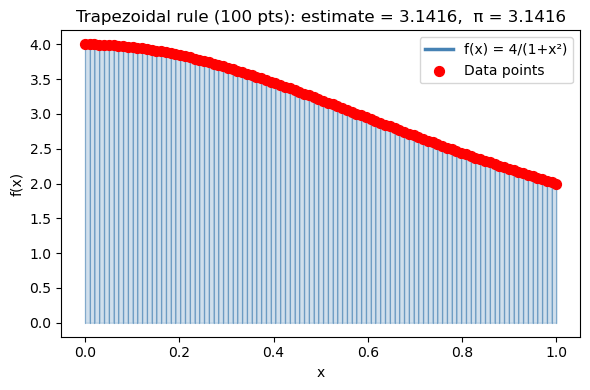

In [29]:
def f_pi(x):
    return 4.0 / (1 + x**2)

# N-point trapezoidal approximation
N = 100
x_trap = np.linspace(0, 1, N)
y_trap = f_pi(x_trap)

# print(x_trap, y_trap)

area_trap = trapezoid(y_trap, x_trap)


print(f"{N}-point trapezoidal estimate: {area_trap:.6f}")
print(f"True value (π):               {np.pi:.6f}")
print(f"Error:                        {abs(area_trap - np.pi):.6f}")

# # Visualize
x_fine = np.linspace(0, 1, 300)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x_fine, f_pi(x_fine), 'steelblue', linewidth=2.5, label='f(x) = 4/(1+x²)', zorder=3)
for i in range(len(x_trap) - 1):
    ax.fill_between([x_trap[i], x_trap[i+1]],
                    [y_trap[i], y_trap[i+1]], alpha=0.25, color='steelblue')
    ax.plot([x_trap[i], x_trap[i]], [0, y_trap[i]], 'steelblue', linewidth=0.8, alpha=0.5)
ax.plot([x_trap[-1], x_trap[-1]], [0, y_trap[-1]], 'steelblue', linewidth=0.8, alpha=0.5)
ax.scatter(x_trap, y_trap, color='red', s=50, zorder=5, label='Data points')
ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.set_title(f'Trapezoidal rule ({N} pts): estimate = {area_trap:.4f},  π = {np.pi:.4f}')
ax.legend()
plt.tight_layout()
plt.show()


### 15.3.2 Heat required from tabulated $C_p$ data

A steam process requires heating from 400 K to 1000 K. Given tabulated heat capacity data:
$$\Delta H = \int_{400}^{1000} C_p(T) \, dT$$

ΔH = ∫Cp dT  =  22485.0 J/mol  =  22.485 kJ/mol


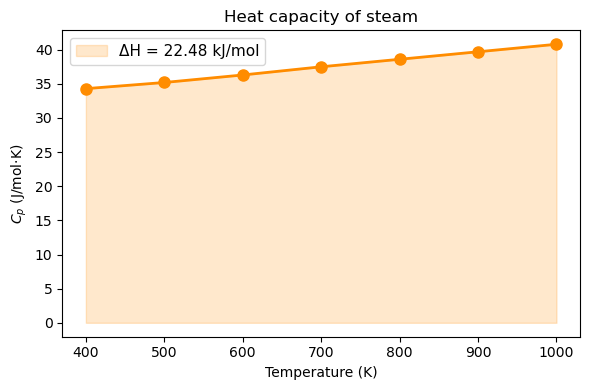

In [30]:
from scipy.integrate import trapezoid

# Tabulated Cp data for steam (J/mol·K) — 7 measurement points
T_data  = np.array([400,  500,  600,  700,  800,  900,  1000])  # K
Cp_data = np.array([34.3, 35.2, 36.3, 37.5, 38.6, 39.7,  40.8])  # J/mol·K

delta_H = trapezoid(Cp_data, T_data)   # J/mol

print(f"ΔH = ∫Cp dT  =  {delta_H:.1f} J/mol  =  {delta_H/1000:.3f} kJ/mol")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(T_data, Cp_data, 'o-', color='darkorange', linewidth=2, markersize=8)
ax.fill_between(T_data, Cp_data, alpha=0.2, color='darkorange',
                label=f'ΔH = {delta_H/1000:.2f} kJ/mol')
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('$C_p$ (J/mol·K)')
ax.set_title('Heat capacity of steam')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

```{note}
Always pass `x` as the second argument: `trapezoid(y, x)`. If you write `trapezoid(y)` alone, it assumes unit spacing ($\Delta x = 1$) and gives a wrong answer when your x-axis has physical units like seconds or Kelvin.
```

(15.4)=
## 15.4 Integration of a Python Function: `scipy.integrate.quad`

### The mathematics: adaptive quadrature

When you have a **Python function** (not just data), `quad` can do far better than the trapezoidal rule. Instead of using equally spaced points, it uses **adaptive quadrature**: it automatically places more sample points in regions where the function changes rapidly and fewer where it is smooth.

Under the hood, `quad` uses **Gaussian quadrature** on subintervals. A $k$-point Gaussian quadrature rule integrates polynomials of degree up to $2k-1$ exactly, by choosing optimal sample locations $x_1, \ldots, x_k$ and weights $w_1, \ldots, w_k$:
$$\int_a^b f(x)\,dx \approx \sum_{j=1}^k w_j\, f(x_j)$$

The positions $x_j$ are the roots of Legendre polynomials — not equally spaced, but strategically placed. `quad` pairs this with an error estimator: if the error is too large on a subinterval, it splits the subinterval in half and tries again. This continues until the estimated error falls below a tolerance ($\sim 10^{-8}$ by default).

The result is near **machine precision** accuracy (~14 significant digits) with far fewer function evaluations than a fine trapezoidal grid would require.

### Key Python syntax

```python
from scipy.integrate import quad

result, error = quad(f, a, b)
```

- **`f`** — a callable (function or lambda) taking a single float and returning a float
- **`a`, `b`** — lower and upper limits of integration (can be `np.inf` for infinite limits)
- **Returns** — a **tuple** of two values:
  - `result` — the integral estimate
  - `error` — an upper bound on the absolute error

```{warning}
`quad` always returns two values. Always unpack both:
```python
result, error = quad(f, a, b)   # correct
result = quad(f, a, b)          # wrong — result is now the whole tuple (float, float)
```

### 15.4.1 Basic usage

Let's verify `quad` on $\int_0^3 x^2\,dx$, whose exact answer we can compute analytically:
$$\int_0^3 x^2\,dx = \left[\frac{x^3}{3}\right]_0^3 = \frac{27}{3} = 9$$

Notice that `quad` achieves essentially machine-precision accuracy (error $\sim 10^{-13}$) — far better than what the trapezoidal rule would give with a moderate number of points.

In [ ]:
# Integrate f(x) = x^2 from 0 to 3  (exact answer = 9)
def f_sq(x):
    return x**2

result, error = quad(f_sq, 0, 3)

print(f"∫₀³ x² dx  =  {result:.10f}")
print(f"Exact answer:   9.0000000000")
print(f"Error estimate: {error:.2e}")

### 15.4.2 The motivation problem solved: $\Delta H$ for N₂

The NIST Shomate equation gives $C_p$ as a polynomial in a reduced temperature $t = T/1000$:

$$C_p(T) = A + Bt + Ct^2 + Dt^3 + \frac{E}{t^2} \qquad [\text{J/mol K}]$$

The enthalpy change from $T_1$ to $T_2$ is then:
$$\Delta H = \int_{T_1}^{T_2} C_p(T)\,dT$$

This is a perfectly well-defined analytic function, so `quad` can evaluate it to near machine precision. We compare it against `trapezoid` with 10 and 100 points to see how accuracy scales with grid resolution — consistent with the $\mathcal{O}(h^2)$ error of the trapezoidal rule.

In [ ]:
# NIST Shomate coefficients for N2 (298-6000 K range)
A, B, C, D, E = 26.09200, 8.218801, -1.976141, 0.159274, 0.044434

def Cp_N2(T):
    t = T / 1000.0
    return A + B*t + C*t**2 + D*t**3 + E/t**2   # J/mol·K

T_low, T_high = 300.0, 1200.0

# --- Method 1: quad (high accuracy) ---
dH_quad, err = quad(Cp_N2, T_low, T_high)

# --- Method 2: trapezoid with only 10 points ---
T_10  = np.linspace(T_low, T_high, 10)
dH_trap10 = trapezoid(Cp_N2(T_10), T_10)

# --- Method 3: trapezoid with 100 points ---
T_100 = np.linspace(T_low, T_high, 100)
dH_trap100 = trapezoid(Cp_N2(T_100), T_100)

print(f"ΔH from 300 K to 1200 K:")
print(f"  quad          : {dH_quad:.4f} J/mol  (error bound: {err:.2e})")
print(f"  trapezoid 10  : {dH_trap10:.4f} J/mol  (error vs quad: {abs(dH_trap10-dH_quad):.4f})")
print(f"  trapezoid 100 : {dH_trap100:.4f} J/mol  (error vs quad: {abs(dH_trap100-dH_quad):.6f})")

# Plot Cp(T)
T_plot = np.linspace(T_low, T_high, 300)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(T_plot, Cp_N2(T_plot), 'steelblue', linewidth=2.5)
ax.fill_between(T_plot, Cp_N2(T_plot), alpha=0.15, color='steelblue',
                label=f'ΔH = {dH_quad/1000:.2f} kJ/mol')
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('$C_p$ (J/mol·K)')
ax.set_title('Heat capacity of N₂  (NIST Shomate equation)')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

(15.5)=
## 15.5 Cumulative Integration: `cumulative_trapezoid`

### The mathematics: a running integral

`trapezoid` collapses the entire integral down to a single number. But sometimes you need the **integral as a function** — not just the total area, but the area accumulated up to every point.

Define the cumulative integral starting from $x_0$:
$$F(x_i) = \int_{x_0}^{x_i} f(x)\,dx$$

Applying the trapezoidal rule interval by interval:
$$F(x_0) = 0$$
$$F(x_1) = F(x_0) + \frac{x_1 - x_0}{2}(f_0 + f_1)$$
$$F(x_2) = F(x_1) + \frac{x_2 - x_1}{2}(f_1 + f_2)$$
$$\vdots$$
$$F(x_i) = F(x_{i-1}) + \frac{x_i - x_{i-1}}{2}(f_{i-1} + f_i)$$

This is simply accumulating trapezoid areas one step at a time. The final element $F(x_n)$ equals what `trapezoid(y, x)` returns.

### Key Python syntax

```python
from scipy.integrate import cumulative_trapezoid

F = cumulative_trapezoid(y, x, initial=0)
```

- **`y`** — array of function values
- **`x`** — array of $x$ positions (always pass with physical units)
- **`initial=0`** — sets $F(x_0) = 0$, so the output has the same length as `y`
- **Returns** — array of cumulative integral values, same length as `y`

```{note}
Without `initial=0`, the output has length `len(y) - 1` (one fewer element, since the first trapezoid needs two points). Using `initial=0` is almost always what you want because it keeps the array length consistent with your `x` and `y` arrays.
```

In [ ]:
# Enthalpy of N2 as a function of temperature, relative to 298 K
T_range = np.linspace(298, 1500, 500)   # K
Cp_range = Cp_N2(T_range)              # J/mol·K

# Cumulative integral: ΔH(T) = ∫₂₉₈ᵀ Cp dT'
dH_cumulative = cumulative_trapezoid(Cp_range, T_range, initial=0)  # J/mol

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(T_range, Cp_range, color='steelblue', linewidth=2)
ax.set_xlabel('Temperature (K)'); ax.set_ylabel('$C_p$ (J/mol·K)')
ax.set_title('Heat capacity of N₂')

ax = axes[1]
ax.plot(T_range, dH_cumulative / 1000, color='darkorange', linewidth=2)
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('ΔH(T) (kJ/mol)')
ax.set_title('Cumulative enthalpy change from 298 K')# + r'$\Delta H(T) = \int_{298}^{T} C_p\,dT\'$')
ax.axhline(0, color='gray', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

print(f"ΔH at T=1200 K: {dH_cumulative[np.argmin(np.abs(T_range-1200))]/1000:.2f} kJ/mol")

(15.6)=
## 15.6 Chemical Engineering Application: PFR Design

### The mole balance and the design equation

A **plug flow reactor (PFR)** is a tubular reactor in which fluid flows steadily through the tube without mixing in the axial direction. Every fluid element sees the same residence time history.

A steady-state mole balance on species A over a differential volume element $dV$ gives:
$$F_A(V) - F_A(V + dV) + r_A\,dV = 0 \implies \frac{dF_A}{dV} = r_A$$

Since conversion is $X = (F_{A0} - F_A)/F_{A0}$, we have $F_A = F_{A0}(1-X)$ and $dF_A = -F_{A0}\,dX$. Substituting:
$$F_{A0}\frac{dX}{dV} = -r_A$$

Rearranging and integrating from $X=0$ to $X=X_f$:
$$\boxed{V = F_{A0} \int_0^{X_f} \frac{dX}{-r_A(X)}}$$

This is the **PFR design equation**. The integrand $1/(-r_A)$ is called the **Levenspiel integrand**. The reactor volume equals $F_{A0}$ times the area under the Levenspiel plot.

### Rate law for this problem

For a liquid-phase second-order reaction A → products, the rate law and concentrations are:
$$-r_A = k C_A^2, \qquad C_A = C_{A0}(1-X)$$
$$\implies -r_A = k C_{A0}^2 (1-X)^2$$

Substituting into the design equation:
$$V = \frac{F_{A0}}{k C_{A0}^2} \int_0^{X_f} \frac{dX}{(1-X)^2}$$

This integral has an analytical solution:
$$\int_0^{X_f} \frac{dX}{(1-X)^2} = \left[\frac{1}{1-X}\right]_0^{X_f} = \frac{X_f}{1-X_f}$$

So the exact answer is:
$$V_\text{exact} = \frac{F_{A0}}{k C_{A0}^2} \cdot \frac{X_f}{1 - X_f}$$

We'll use this to verify the numerical result from `quad`.

| Parameter | Value |
|-----------|-------|
| Rate constant $k$ | 0.05 L/mol·s |
| Inlet concentration $C_{A0}$ | 2.0 mol/L |
| Molar feed rate $F_{A0}$ | 5.0 mol/s |
| Target conversion $X_f$ | 80% |

### Part A: The Levenspiel plot

The integrand $1/(-r_A)$ is the **Levenspiel integrand** — plotting it vs. conversion $X$ is standard ChE practice for reactor design.

For our second-order rate law:
$$\frac{1}{-r_A} = \frac{1}{k C_{A0}^2 (1-X)^2}$$

As $X \to 1$, $(1-X)^2 \to 0$, so the integrand diverges to infinity. This tells you physically that it becomes increasingly "expensive" (in volume) to achieve the last few percent of conversion — the reaction slows down dramatically as reactant is depleted.

The **reactor volume** is graphically the shaded area under this curve from $X=0$ to $X=X_f$, scaled by $F_{A0}$.

In [ ]:
k    = 0.05    # L/mol·s
C_A0 = 2.0     # mol/L
F_A0 = 5.0     # mol/s
X_f  = 0.80    # target conversion

def rate(X):
    return k * C_A0**2 * (1 - X)**2   # -r_A  (mol/L·s)

def levenspiel(X):
    return 1.0 / rate(X)              # 1/(-r_A)

X_plot = np.linspace(0, 0.95, 300)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(X_plot, levenspiel(X_plot), 'steelblue', linewidth=2.5)
X_shade = np.linspace(0, X_f, 300)
ax.fill_between(X_shade, levenspiel(X_shade), alpha=0.2, color='steelblue',
                label=f'Area = V/F_{{A0}}  at X={X_f}')
ax.axvline(X_f, color='red', linestyle='--', linewidth=1.5, label=f'X_f = {X_f}')
ax.set_xlabel('Conversion X')
ax.set_ylabel(r'$1/(-r_A)$  (L·s/mol)')
ax.set_title('Levenspiel plot: area = reactor volume / F$_{A0}$')
ax.set_ylim(0, 80)
ax.legend()
plt.tight_layout()
plt.show()

### Part B: Numerical integration with `quad`

We compute $V = F_{A0}\int_0^{X_f} \frac{dX}{-r_A(X)}$ numerically and compare against the exact analytical result:
$$V_\text{exact} = \frac{F_{A0}}{k C_{A0}^2} \cdot \frac{X_f}{1-X_f} = \frac{5.0}{0.05 \times 4.0} \cdot \frac{0.8}{0.2} = 25 \cdot 4 = 100 \text{ L}$$

A relative error of $\sim 10^{-13}$ confirms that `quad` achieves machine-precision accuracy.

In [ ]:
integral, err = quad(levenspiel, 0, X_f)
V_numerical = F_A0 * integral

# Analytical answer for 2nd-order: V = (F_A0 / k*C_A0^2) * X_f/(1-X_f)
V_exact = (F_A0 / (k * C_A0**2)) * (X_f / (1 - X_f))

print(f"PFR volume for X = {X_f:.0%} conversion:")
print(f"  Numerical (quad): V = {V_numerical:.4f} L")
print(f"  Analytical:       V = {V_exact:.4f} L")
print(f"  Relative error:   {abs(V_numerical - V_exact)/V_exact:.2e}")

### Part C: Reactor sizing chart — conversion vs. volume

Instead of a single volume target, we can use `cumulative_trapezoid` on the Levenspiel integrand to build a full design chart:
$$V(X) = F_{A0} \int_0^{X} \frac{dX'}{-r_A(X')}$$

Each point on this curve answers the question: "What volume do I need to reach conversion $X$?" This is useful for comparing reactor options or evaluating sensitivity to the conversion target.

In [ ]:
X_arr  = np.linspace(0, 0.95, 500)
V_arr  = F_A0 * cumulative_trapezoid(levenspiel(X_arr), X_arr, initial=0)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(V_arr, X_arr, 'steelblue', linewidth=2.5)
ax.axhline(X_f,         color='red',  linestyle='--', linewidth=1.5, label=f'X = {X_f}')
ax.axvline(V_numerical, color='red',  linestyle='--', linewidth=1.5, label=f'V = {V_numerical:.1f} L')
ax.scatter([V_numerical], [X_f], color='red', s=80, zorder=5)
ax.set_xlabel('Reactor volume V (L)')
ax.set_ylabel('Conversion X')
ax.set_title('PFR design chart: conversion vs. volume')
ax.legend()
plt.tight_layout()
plt.show()

## Chapter 15 Summary

| Task | Tool | Key syntax |
|------|------|-----------|
| Derivative of discrete data | `np.gradient` | `np.gradient(y, x)` |
| Integral of discrete data | `scipy.integrate.trapezoid` | `trapezoid(y, x)` |
| Integral of a Python function | `scipy.integrate.quad` | `result, err = quad(f, a, b)` |
| Running cumulative integral | `scipy.integrate.cumulative_trapezoid` | `cumulative_trapezoid(y, x, initial=0)` |
| Pass parameters to `quad` | `args=` keyword | `quad(f, a, b, args=(p1, p2))` |

### When to use which tool

- **Have discrete data?** → `trapezoid` (or `np.gradient` for derivatives)
- **Have a Python function?** → `quad` for highest accuracy
- **Need the value at every point, not just the endpoint?** → `cumulative_trapezoid`
- **More points always helps** `trapezoid`, but `quad` is already near machine precision